<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ml-labs/GroceryKMeanBisectingKMeanWeek7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Schema:
root
 |-- Channel: integer (nullable = true)
 |-- Region: integer (nullable = true)
 |-- Fresh: integer (nullable = true)
 |-- Milk: integer (nullable = true)
 |-- Grocery: integer (nullable = true)
 |-- Frozen: integer (nullable = true)
 |-- Detergents_Paper: integer (nullable = true)
 |-- Delicassen: integer (nullable = true)


Row count: 440

Sample data:
+-------+------+-----+----+-------+------+----------------+----------+
|Channel|Region|Fresh|Milk|Grocery|Frozen|Detergents_Paper|Delicassen|
+-------+------+-----+----+-------+------+----------------+----------+
|      2|     3|12669|9656|   7561|   214|            2674|      1338|
|      2|     3| 7057|9810|   9568|  1762|            3293|      1776|
|      2|     3| 6353|8808|   7684|  2405|            3516|      7844|
|      1|     3|13265|1196|   4221|  6404|             507|      178

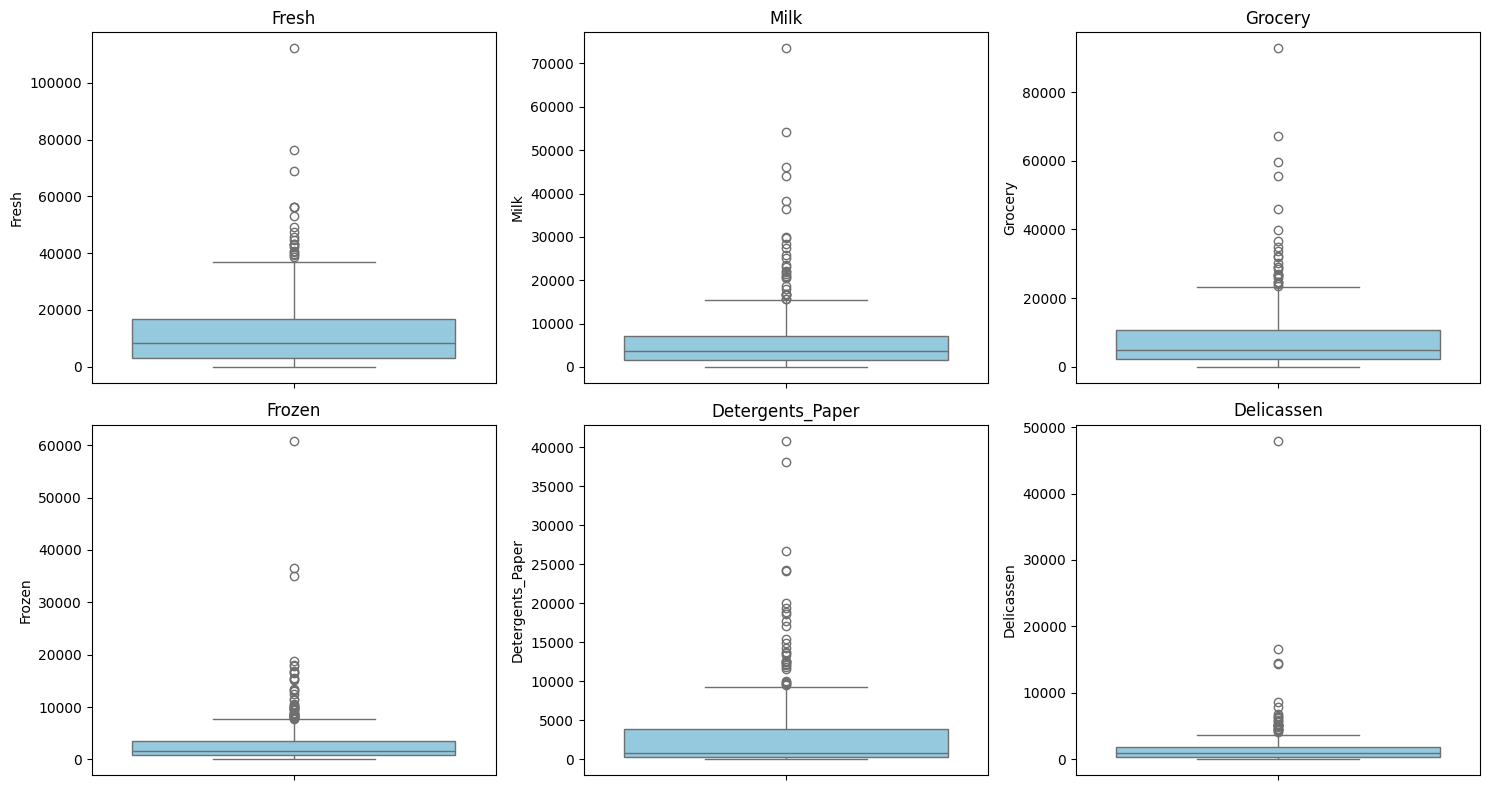

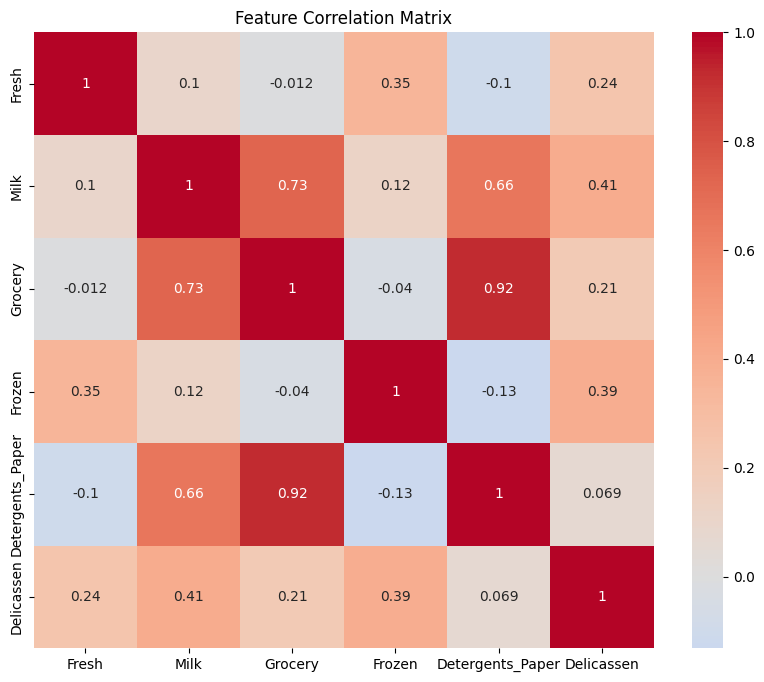


Clustering Algorithm Comparison:
k    K-Means Silhouette  BKM Silhouette      K-Means WSSSE  BKM WSSSE      
2    0.7959              0.7959              619.01         619.01         
3    0.6392              0.5488              455.90         472.18         
4    0.5511              0.5695              317.93         333.30         
5    0.5079              0.4570              264.71         273.36         
6    0.4996              0.5490              249.94         234.11         
7    0.5070              0.5211              231.42         224.19         


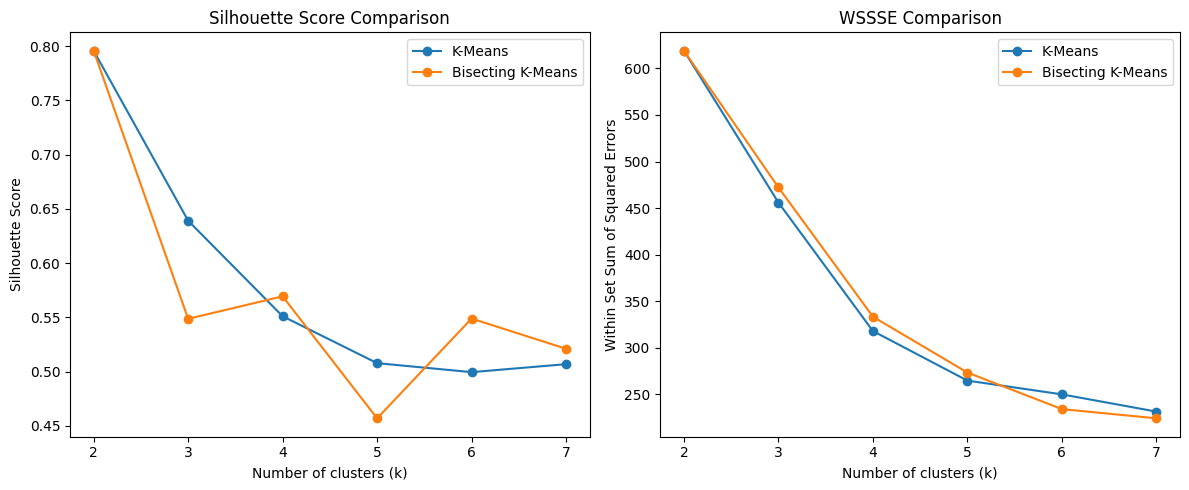


Optimal number of clusters based on silhouette score: 2.0

K-Means Clustering Results:
+-----------+-----+
|kmeans_pred|count|
+-----------+-----+
|          0|  393|
|          1|   47|
+-----------+-----+


Bisecting K-Means Clustering Results:
+--------+-----+
|bkm_pred|count|
+--------+-----+
|       0|  440|
+--------+-----+




Cluster Centers Comparison:
K-Means Cluster Centers:
Cluster 0: [ 0.00205456 -0.24070724 -0.25188105]
Cluster 1: [-0.01717963  2.0127222   2.10615427]

Bisecting K-Means Cluster Centers:
Cluster 0: [-2.78565050e-16 -9.41670984e-16 -2.27091073e-16]


In [3]:
# Install required packages
!pip install pyspark plotly

# Initialize Spark Session
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master("local") \
    .appName("GroceryClustering") \
    .config('spark.ui.port', '8080') \
    .getOrCreate()

# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
path = '/content/drive/MyDrive/UEL/Grocery.csv'
df = spark.read.csv(path, inferSchema=True, header=True)

## Data Exploration
print("Dataset Schema:")
df.printSchema()
print(f"\nRow count: {df.count()}")
print("\nSample data:")
df.show(5)

# Check for missing values
from pyspark.sql.functions import col, isnan, when, count
print("\nMissing values:")
df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# Convert to Pandas for visualization
import pandas as pd
data_pd = df.toPandas()

## Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Boxplots for numerical features
numerical_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
plt.figure(figsize=(15, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=data_pd[feature], color='skyblue')
    plt.title(feature)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_pd[numerical_features].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## Feature Engineering
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Select features for clustering
clustering_cols = ['Fresh', 'Milk', 'Grocery']

# Assemble features
assembler = VectorAssembler(inputCols=clustering_cols, outputCol="raw_features")
feature_df = assembler.transform(df)

# Scale features
scaler = StandardScaler(inputCol="raw_features", outputCol="features",
                        withStd=True, withMean=True)
scaler_model = scaler.fit(feature_df)
scaled_data = scaler_model.transform(feature_df)

# Split data
train_data, test_data = scaled_data.randomSplit([0.7, 0.3], seed=42)

## Clustering Implementation
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator

def evaluate_clustering(k_values, train_data, test_data):
    results = []

    for k in k_values:
        # K-Means
        kmeans = KMeans(featuresCol='features', predictionCol='kmeans_pred', k=k, seed=42)
        kmeans_model = kmeans.fit(train_data)
        kmeans_pred = kmeans_model.transform(test_data)
        kmeans_evaluator = ClusteringEvaluator(predictionCol='kmeans_pred')
        kmeans_silhouette = kmeans_evaluator.evaluate(kmeans_pred)

        # Bisecting K-Means
        bkm = BisectingKMeans(featuresCol='features', predictionCol='bkm_pred', k=k, seed=42)
        bkm_model = bkm.fit(train_data)
        bkm_pred = bkm_model.transform(test_data)
        bkm_evaluator = ClusteringEvaluator(predictionCol='bkm_pred')
        bkm_silhouette = bkm_evaluator.evaluate(bkm_pred)

        results.append({
            'k': k,
            'kmeans_silhouette': kmeans_silhouette,
            'bkm_silhouette': bkm_silhouette,
            'kmeans_wssse': kmeans_model.summary.trainingCost,
            'bkm_wssse': bkm_model.summary.trainingCost
        })

    return results

# Evaluate for k values 2 through 7
k_values = range(2, 8)
results = evaluate_clustering(k_values, train_data, test_data)

# Convert results to pandas for visualization
results_df = pd.DataFrame(results)

# Print comparison results
print("\nClustering Algorithm Comparison:")
print(f"{'k':<5}{'K-Means Silhouette':<20}{'BKM Silhouette':<20}{'K-Means WSSSE':<15}{'BKM WSSSE':<15}")
for res in results:
    print(f"{res['k']:<5}{res['kmeans_silhouette']:<20.4f}{res['bkm_silhouette']:<20.4f}"
          f"{res['kmeans_wssse']:<15.2f}{res['bkm_wssse']:<15.2f}")

# Visualization of results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results_df['k'], results_df['kmeans_silhouette'], marker='o', label='K-Means')
plt.plot(results_df['k'], results_df['bkm_silhouette'], marker='o', label='Bisecting K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results_df['k'], results_df['kmeans_wssse'], marker='o', label='K-Means')
plt.plot(results_df['k'], results_df['bkm_wssse'], marker='o', label='Bisecting K-Means')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within Set Sum of Squared Errors')
plt.title('WSSSE Comparison')
plt.legend()

plt.tight_layout()
plt.show()

## Final Models with Optimal k
# Determine optimal k (based on silhouette score)
optimal_k = results_df.loc[results_df['kmeans_silhouette'].idxmax()]['k']

print(f"\nOptimal number of clusters based on silhouette score: {optimal_k}")

# K-Means final model
final_kmeans = KMeans(featuresCol='features', predictionCol='kmeans_pred', k=optimal_k, seed=42)
final_kmeans_model = final_kmeans.fit(scaled_data)
kmeans_results = final_kmeans_model.transform(scaled_data)

# Bisecting K-Means final model
final_bkm = BisectingKMeans(featuresCol='features', predictionCol='bkm_pred', k=optimal_k, seed=42)
final_bkm_model = final_bkm.fit(scaled_data)
bkm_results = final_bkm_model.transform(scaled_data)

# Show cluster distributions
print("\nK-Means Clustering Results:")
kmeans_results.groupBy("kmeans_pred").count().orderBy("kmeans_pred").show()

print("\nBisecting K-Means Clustering Results:")
bkm_results.groupBy("bkm_pred").count().orderBy("bkm_pred").show()

## Cluster Visualization
def plot_clusters_3d(results_pd, pred_col, title):
    fig = px.scatter_3d(results_pd, x='Fresh', y='Milk', z='Grocery',
                        color=pred_col, title=title,
                        color_continuous_scale=px.colors.sequential.Viridis)
    fig.update_layout(scene=dict(xaxis_title='Fresh (scaled)',
                                yaxis_title='Milk (scaled)',
                                zaxis_title='Grocery (scaled)'))
    fig.show()

# Convert to pandas for visualization
kmeans_results_pd = kmeans_results.toPandas()
bkm_results_pd = bkm_results.toPandas()

# Plot K-Means clusters
plot_clusters_3d(kmeans_results_pd, 'kmeans_pred', f'K-Means Clustering (k={optimal_k})')

# Plot Bisecting K-Means clusters
plot_clusters_3d(bkm_results_pd, 'bkm_pred', f'Bisecting K-Means Clustering (k={optimal_k})')

## Cluster Centers Comparison
print("\nCluster Centers Comparison:")
print("K-Means Cluster Centers:")
for i, center in enumerate(final_kmeans_model.clusterCenters()):
    print(f"Cluster {i}: {center}")

print("\nBisecting K-Means Cluster Centers:")
for i, center in enumerate(final_bkm_model.clusterCenters()):
    print(f"Cluster {i}: {center}")

# Stop Spark session
spark.stop()